# Problem 1 - Little Peak

For the following problem, let's try to follow the code as suggested in the BlueQubit [tutorial](https://app.bluequbit.io/tutorial/91OgcR5O1GqFpues)

First load the relevant libraries

In [1]:
# --- Setup ---
import os
import time
import warnings

# Optional internal flags you were using
# os.environ["BLUEQUBIT_PPS_DO_NO_USE_PARALLEL_COMPUTE"] = "1"
os.environ["BLUEQUBIT_DEQART_INTERNAL_DISABLE_STRICT_VALIDATIONS"] = "1"

warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from qiskit import QuantumCircuit, transpile
import bluequbit

# Optional: load .env file if present (pip install python-dotenv)
try:
    from dotenv import load_dotenv
    load_dotenv()
except Exception:
    pass

# --- Auth ---
token = os.getenv("BLUEQUBIT_API_TOKEN")
if not token:
    raise RuntimeError(
        "Missing BLUEQUBIT_API_TOKEN. Set it in your shell or in a local .env file."
    )

bq = bluequbit.init(token)
print("BlueQubit client initialized successfully.")

[BQ-PYTHON-SDK][WARNING] - Beta version 0.18.1b1 of BlueQubit Python SDK is being used.


[BQ-PYTHON-SDK][INFO] - There is a newer version of BlueQubit Python SDK available on PyPI. We recommend upgrading. Run 'pip install --upgrade bluequbit' to upgrade from your version 0.18.1b1 to 0.18.3b1.
BlueQubit client initialized successfully.


Now, we can load the corresponding circuit

In [2]:
qc = QuantumCircuit.from_qasm_file('problems/P1_little_peak.qasm')

Let's visualize the circuit

Gates: OrderedDict([('ry', 4), ('x', 2)])


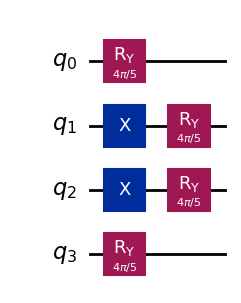

In [3]:
print(f"Gates: {qc.count_ops()}")
qc.draw("mpl", fold=-1)

This is a very simple circuit that could be calculated by hand.
Let's run a simulation of this circuit with what we find in bluequbit's [tutorial](https://app.bluequbit.io/tutorial/91OgcR5O1GqFpues)

In [4]:
results = bq.run(qc)
probs = results.get_counts()

top10_probs = dict(sorted(probs.items(), key=lambda x: x[1], reverse=True)[:10]) # get top 10
top10_probs 

[BQ-PYTHON-SDK][INFO] - Submitted: Job ID: TzHS8s0dv8j4GeWO, device: cpu, run status: COMPLETED, created on: 2026-03-05 20:13:09 UTC, cost: $0.00, run time: 24 ms, queue time: 113 ms, num qubits: 4


{'1001': 0.6693459153175354,
 '1011': 0.07066473364830017,
 '1101': 0.07066473364830017,
 '0001': 0.07066471874713898,
 '1000': 0.07066471874713898,
 '0011': 0.007460273802280426,
 '0101': 0.007460273802280426,
 '1010': 0.007460273802280426,
 '1100': 0.007460273802280426,
 '1111': 0.007460273802280426}

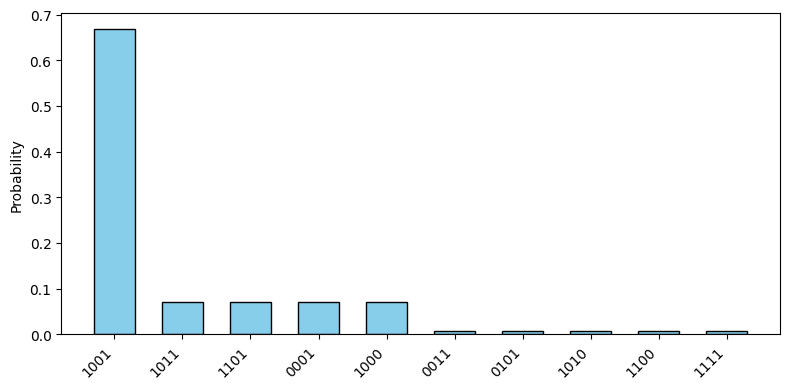

In [5]:
import matplotlib.pyplot as plt

bitstrings = list(top10_probs.keys())
probs = list(top10_probs.values())

plt.figure(figsize=(8, 4))
plt.bar(range(len(probs)), probs, tick_label=bitstrings, color='skyblue', edgecolor='black', width=0.6)
plt.ylabel("Probability")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

It shows that `1001` is by far the most probable state to get with this quantum circuit.